# Évaluer un premier modèle : métriques et cross-validation

**Jour 2 — chapitre 01 : Qu'est-ce qu'un bon modèle ?**

## Mise en situation

Au jour 1, le dataset Titanic a été exploré (target, features, hypothèses métier, valeurs
manquantes), sans construire de modèle. On construit ici un premier modèle, volontairement
simple, pour répondre à la question du chapitre : est-ce un bon modèle ?

Un bon modèle est un modèle qui **généralise** : il prédit correctement la survie de
passagers qu'il n'a jamais vus pendant l'entraînement. Pour en juger, ce notebook avance
en trois temps :

1. **Construire** le modèle et le comparer à un modèle naïf de référence.
2. **Mesurer** ses erreurs : matrice de confusion, precision, recall, F1-score, courbe ROC.
3. **Fiabiliser** la mesure : cross-validation.

Le nettoyage des données est le sujet du chapitre suivant. Ce premier modèle utilise donc
uniquement les colonnes sans valeurs manquantes : `Pclass`, `Sex`, `SibSp`, `Parch` et
`Fare`. `Age` sera exploitable une fois ses valeurs manquantes traitées (notebook 03).

Comme au jour 1, ce notebook charge les données via `seaborn` pour rester autonome. En
formation réelle, utilisez le `train.csv` de la compétition Kaggle *Titanic*.

In [2]:
import pandas as pd
import seaborn as sns

titanic_raw = sns.load_dataset("titanic")
titanic = titanic_raw.rename(columns={
    "survived": "Survived",
    "pclass": "Pclass",
    "sex": "Sex",
    "sibsp": "SibSp",
    "parch": "Parch",
    "fare": "Fare",
})[["Survived", "Pclass", "Sex", "SibSp", "Parch", "Fare"]].copy()

# Sex contient du texte ("male" / "female") : un modele attend des nombres, on la code en 0/1.
# L'encodage des variables categorielles est detaille au chapitre Feature engineering.
titanic["Sex_male"] = (titanic["Sex"] == "male").astype(int)

features = ["Pclass", "Sex_male", "SibSp", "Parch", "Fare"]
X = titanic[features]
y = titanic["Survived"]

print("Valeurs manquantes dans les features retenues :", X.isnull().sum().sum())
X.head()

Valeurs manquantes dans les features retenues : 0


,Pclass,Sex_male,SibSp,Parch,Fare
0,3,1,1,0,7.2500
1,1,0,1,0,71.2833
2,3,0,0,0,7.9250
3,1,0,1,0,53.1000
4,3,1,0,0,8.0500


## Étape 1 — Construire un premier modèle

**Question de réflexion :** quel algorithme vu au jour 1 choisir pour un premier modèle de
classification binaire ? Et sur quelles données vérifier ses prédictions ?

On choisit la **régression logistique**, vue au jour 1. Comme le veut la règle d'or du
découpage train / validation / test (jour 1), 20 % des passagers sont mis de côté dans un
jeu de test : le modèle ne les voit pas pendant l'entraînement.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modele = LogisticRegression(max_iter=5000)
modele.fit(X_train, y_train)

predictions = modele.predict(X_test)

# Dix premiers passagers du jeu de test : prediction du modele face a la realite
apercu = X_test.head(10).copy()
apercu["Survived_reel"] = y_test.head(10)
apercu["Survived_predit"] = predictions[:10]
apercu[["Survived_reel", "Survived_predit"]]

,Survived_reel,Survived_predit
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1
290,1,1
300,1,1
333,0,0
208,1,1
136,1,1


**Ce qu'on observe** : pour chaque passager du jeu de test, le modèle prédit 0 (décédé) ou
1 (survivant). Sur ces dix premiers passagers, il se trompe une fois. Reste à mesurer
combien de fois il se trompe sur l'ensemble du jeu de test, et surtout de quelle façon : c'est
le rôle des métriques.

## Étape 2 — L'accuracy, et le modèle naïf de référence

**Question de réflexion :** la proportion de bonnes réponses (l'accuracy) suffit-elle à dire
qu'un modèle est bon ? À quoi faut-il la comparer ?

In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report 

# Modele naif : predit toujours la classe la plus frequente du jeu d'entrainement (decede)
modele_naif = DummyClassifier(strategy="most_frequent")
modele_naif.fit(X_train, y_train)
predictions_naif = modele_naif.predict(X_test)

print("Accuracy du premier modèle :", round(accuracy_score(y_test, predictions), 3))
print("Accuracy du modèle naïf    :", round(accuracy_score(y_test, predictions_naif), 3))
print("Part de décédés dans le jeu de test :", round((y_test == 0).mean(), 3))


Accuracy du premier modèle : 0.788
Accuracy du modèle naïf    : 0.587
Part de décédés dans le jeu de test : 0.587


**Ce qu'on observe** : le premier modèle a une accuracy de 0,788. Mais un modèle naïf, qui
prédit « décédé » pour tout le monde sans rien apprendre, atteint déjà 0,587 : c'est simplement
la part de décédés dans le jeu de test. Une accuracy ne s'interprète donc jamais seule, mais
face à une référence.

L'accuracy a une autre limite : elle compte les erreurs sans dire lesquelles. Le modèle naïf
ne trouve aucun survivant, et son score ne le montre pas.

## Étape 3 — La matrice de confusion : quelles erreurs ?

**Question de réflexion :** parmi les erreurs du modèle, combien de survivants a-t-il
prédits décédés ? Combien de décédés a-t-il prédits survivants ?

Convention : la classe **positive** est « survivant » (`Survived = 1`). Les matrices
ci-dessous sont disposées comme en cours : le positif en premier, les vrais positifs en
haut à gauche.

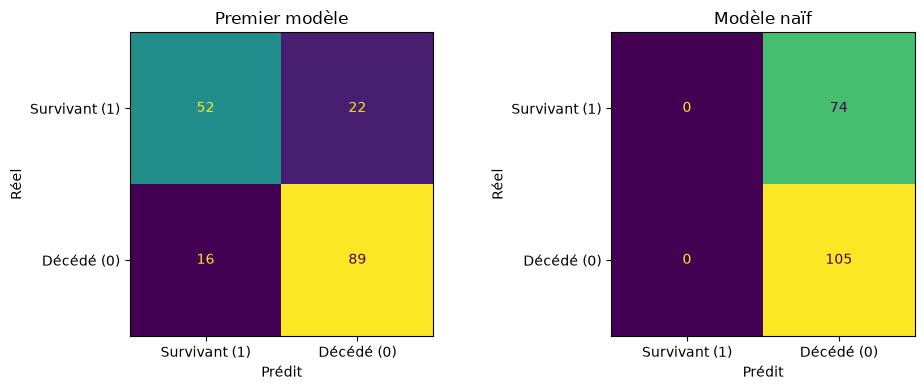

Premier modèle : VP = 52, FN = 22, FP = 16, VN = 89


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, titre in [
    (axes[0], predictions, "Premier modèle"),
    (axes[1], predictions_naif, "Modèle naïf"),
]:
    # labels=[1, 0] : le positif (survivant) en premier, comme en cours
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, labels=[1, 0],
        display_labels=["Survivant (1)", "Décédé (0)"],
        colorbar=False, ax=ax,
    )
    ax.set_title(titre)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
plt.tight_layout()
plt.show()

vn, fp, fn, vp = confusion_matrix(y_test, predictions).ravel()
print(f"Premier modèle : VP = {vp}, FN = {fn}, FP = {fp}, VN = {vn}")

**Ce qu'on observe** : le premier modèle retrouve 52 survivants (VP) mais en manque 22 (FN),
et annonce à tort 16 survivants parmi les décédés (FP). Le modèle naïf n'a aucun vrai positif :
il manque les 74 survivants du jeu de test. Son accuracy de 0,587 cachait complètement
ce défaut.

## Étape 4 — Precision, recall et F1-score

**Question de réflexion :** comment résumer les quatre cases de la matrice en quelques
chiffres, qui répondent chacun à une question précise ?

- **Precision** = VP / (VP + FP) : quand le modèle annonce un survivant, a-t-il raison ?
- **Recall** = VP / (VP + FN) : parmi les vrais survivants, combien le modèle en retrouve-t-il ?
- **F1-score** : moyenne harmonique des deux, élevée seulement si les deux le sont.

In [6]:
from sklearn.metrics import f1_score, precision_score, recall_score

def metriques(y_reel, y_predit):
    return {
        "accuracy": accuracy_score(y_reel, y_predit),
        # zero_division=0 : le modele naif ne predit aucun positif, sa precision vaut 0 par convention
        "precision": precision_score(y_reel, y_predit, zero_division=0),
        "recall": recall_score(y_reel, y_predit),
        "f1": f1_score(y_reel, y_predit),
    }

pd.DataFrame({
    "Premier modèle": metriques(y_test, predictions),
    "Modèle naïf": metriques(y_test, predictions_naif),
}).round(3)

,Premier modèle,Modèle naïf
accuracy,0.788,0.587
precision,0.765,0.000
recall,0.703,0.000
f1,0.732,0.000


**Ce qu'on observe** : la precision du premier modèle est de 0,765 (quand il annonce un
survivant, il a raison environ 3 fois sur 4) et son recall de 0,703 (il retrouve 70 % des
survivants). Le F1-score, 0,732, résume ce compromis. Le modèle naïf obtient 0 partout sauf en
accuracy : ces métriques révèlent ce que l'accuracy masquait.

La métrique à privilégier dépend du coût métier des erreurs : en détection de fraude, rater
une fraude (FN) coûte souvent plus cher qu'une fausse alerte (FP), on privilégie alors le
recall. La MAPE, vue dans le même tableau des métriques, est une métrique de régression :
elle ne s'applique pas à ce problème de classification.

## Étape 5 — Le seuil de décision, la courbe ROC et l'AUC

**Question de réflexion :** la régression logistique calcule une probabilité de survie,
puis prédit « survivant » si cette probabilité atteint 0,5. Que deviennent la precision et
le recall si on change ce seuil ?

In [7]:
probas = modele.predict_proba(X_test)[:, 1]

lignes = []
for seuil in [0.3, 0.5, 0.7]:
    predictions_seuil = (probas >= seuil).astype(int)
    lignes.append({"seuil": seuil, **metriques(y_test, predictions_seuil)})

pd.DataFrame(lignes).round(3)

,seuil,accuracy,precision,recall,f1
0,0.3,0.765,0.663,0.878,0.756
1,0.5,0.788,0.765,0.703,0.732
2,0.7,0.765,0.900,0.486,0.632


**Ce qu'on observe** : abaisser le seuil à 0,3 fait monter le recall (0,878) mais baisser la
precision (0,663) : le modèle trouve plus de survivants, au prix de plus de fausses alertes.
Monter le seuil à 0,7 fait l'inverse (precision 0,900, recall 0,486). Chaque seuil donne
une autre matrice de confusion. Pour juger le modèle sans dépendre d'un seuil, on trace la
courbe ROC.

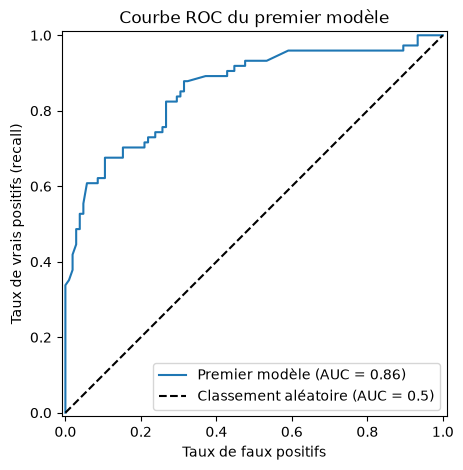

AUC du premier modèle : 0.858


In [8]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(
    y_test, probas, name="Premier modèle", ax=ax,
    plot_chance_level=True,
    chance_level_kw={"label": "Classement aléatoire (AUC = 0.5)"},
)
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs (recall)")
ax.set_title("Courbe ROC du premier modèle")
plt.show()

print("AUC du premier modèle :", round(roc_auc_score(y_test, probas), 3))

**Ce qu'on observe** : la courbe ROC montre, pour tous les seuils possibles à la fois, le
taux de vrais positifs (le recall) face au taux de faux positifs. La diagonale correspond à un
classement au hasard (AUC = 0,5) : c'est aussi ce qu'obtient le modèle naïf, qui donne la même
probabilité à tout le monde. Le premier modèle s'en éloigne nettement vers le coin
haut-gauche, avec une AUC de 0,858.

## Étape 6 — Un seul découpage suffit-il ? La cross-validation

**Question de réflexion :** toutes les mesures précédentes viennent d'un seul découpage
train / test (`random_state=42`). Aurait-on obtenu les mêmes avec un autre découpage ?

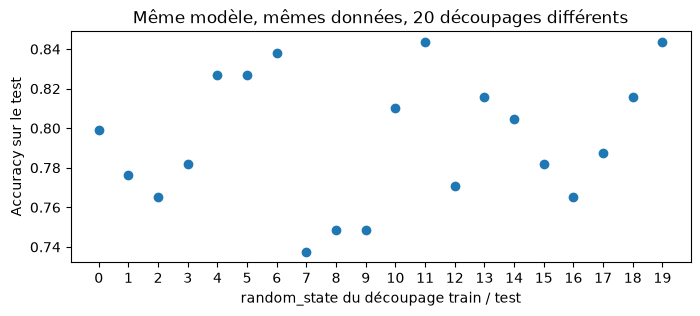

Accuracy la plus basse : 0.737
Accuracy la plus haute : 0.844


In [9]:
accuracies = []
for graine in range(20):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=graine)
    modele_graine = LogisticRegression(max_iter=5000).fit(X_tr, y_tr)
    accuracies.append(accuracy_score(y_te, modele_graine.predict(X_te)))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(20), accuracies, marker="o", linestyle="none")
ax.set_xticks(range(20))
ax.set_xlabel("random_state du découpage train / test")
ax.set_ylabel("Accuracy sur le test")
ax.set_title("Même modèle, mêmes données, 20 découpages différents")
plt.show()

print("Accuracy la plus basse :", round(min(accuracies), 3))
print("Accuracy la plus haute :", round(max(accuracies), 3))

**Ce qu'on observe** : le même modèle, entraîné sur les mêmes données, obtient entre 0,737
et 0,844 d'accuracy selon le seul hasard du découpage. Avec un score unique, on pourrait croire
à une amélioration, ou à une dégradation, qui n'existe pas.

C'est ce que corrige la **cross-validation** : le jeu d'entraînement est découpé en 5 plis,
chaque pli sert une fois de validation pendant que les 4 autres servent à l'entraînement, et
on retient la moyenne des 5 scores. Toutes les métriques vues plus haut peuvent être
calculées de cette façon.

In [20]:
from sklearn.model_selection import cross_val_score, cross_validate

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

resultats_cv = cross_validate(
    LogisticRegression(max_iter=5000), X_train, y_train, cv=5, scoring=scoring
)

accuracy_cv_naif = cross_val_score(modele_naif, X_train, y_train, cv=5).mean()
print("Accuracy moyenne du modèle naïf en cross-validation :", round(accuracy_cv_naif, 3))

pd.DataFrame({
    "moyenne (5 plis)": [resultats_cv[f"test_{m}"].mean() for m in scoring],
    "écart-type": [resultats_cv[f"test_{m}"].std() for m in scoring],
    "moyenne (5 plis) du modèle naïf": [accuracy_cv_naif] * len(scoring),
}, index=scoring).round(3)

Accuracy moyenne du modèle naïf en cross-validation : 0.624


,moyenne (5 plis),écart-type,moyenne (5 plis) du modèle naïf
accuracy,0.798,0.024,0.624
precision,0.763,0.034,0.624
recall,0.671,0.066,0.624
f1,0.712,0.046,0.624
roc_auc,0.826,0.034,0.624


**Ce qu'on observe** : en cross-validation, le premier modèle obtient une accuracy moyenne de
0,798 (contre 0,624 pour le modèle naïf), un F1-score de 0,712 et une AUC de 0,826. L'écart-type
indique la stabilité de chaque mesure d'un pli à l'autre : le recall (± 0,066) est ici la
mesure la moins stable.

Jusqu'ici, le jeu de test a servi à découvrir les métriques. Dans la suite de la journée, on
compare et on règle les modèles en cross-validation sur le jeu d'entraînement ; le jeu de
test ne sert qu'une fois, à la fin, pour vérifier le modèle retenu.

## Étape 7 — Quelle est la part de chaque variable dans la prédiction ?

**Question de réflexion :** le modèle s'appuie sur cinq colonnes. Pèsent-elles toutes autant
dans sa décision ?

La régression logistique donne un **coefficient** par colonne : c'est le poids de cette colonne
dans la prédiction. Un coefficient se lit par unité de la colonne (un point de `Pclass`, un euro
de `Fare`) ; pour comparer des colonnes d'échelles différentes, on le ramène à l'écart-type de
la colonne. Les poids obtenus sont ensuite exprimés en pourcentage du total.

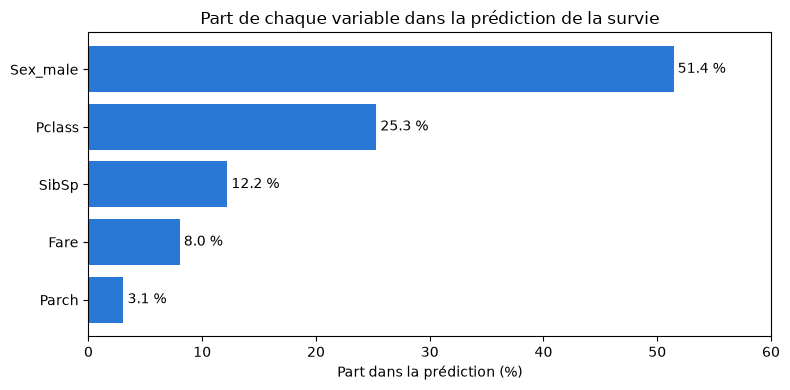

In [ ]:
# Poids de chaque colonne dans la prediction, ramene a l'echelle de la colonne puis en % du total
poids = abs(modele.coef_[0] * X_train.std().values)
part = pd.Series(100 * poids / poids.sum(), index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
barres = ax.barh(part.index, part.values, color="#2a78d6")
ax.bar_label(barres, fmt="%.1f %%", padding=3)
ax.set_xlim(0, 60)
ax.set_xlabel("Part dans la prédiction (%)")
ax.set_title("Part de chaque variable dans la prédiction de la survie")
plt.tight_layout()
plt.show()

**Ce qu'on observe** : le sexe pèse à lui seul 51,4 % de la prédiction, la classe du billet
25,3 % : à eux deux, ils font plus des trois quarts de la décision du modèle. `SibSp` (12,2 %),
`Fare` (8,0 %) et `Parch` (3,1 %) complètent à la marge.

Ces parts disent le poids de chaque colonne, pas le sens de son effet : le coefficient de
`Sex_male` est négatif, être un homme fait baisser la probabilité de survie.

**À retenir pour le débriefing** :

- Un bon modèle se juge **face à une référence** (ici le modèle naïf), avec **la métrique qui
  reflète le coût des erreurs**, et grâce à une **estimation fiable** (cross-validation).
- L'accuracy seule peut tromper : la matrice de confusion, la precision, le recall et le
  F1-score disent quelles erreurs le modèle commet ; la courbe ROC et l'AUC le jugent
  indépendamment du seuil.
- Ce premier modèle, construit sur 5 colonnes sans valeurs manquantes, obtient 0,798
  d'accuracy en cross-validation : c'est le score à battre dans la suite de la journée
  (notebook 05).

Le prochain notebook pose la question suivante : que se passe-t-il quand un modèle est trop
simple, ou trop complexe ?

## Pour aller plus loin — Quelle confiance accorder à chaque prédiction ?

**Question de réflexion :** l'étape 6 a montré qu'un autre jeu d'entraînement donne un autre
score global. Donne-t-il aussi une autre probabilité de survie pour un même passager ? Et le
modèle est-il aussi sûr de lui pour tous les passagers ?

Pour le mesurer, on entraîne 50 régressions logistiques, chacune sur un **tirage avec remise**
(bootstrap) du jeu d'entraînement : chaque tirage compte autant de passagers que le jeu
d'origine, certains en plusieurs exemplaires, d'autres absents. Pour chaque passager du jeu de
test, on compare ensuite les 50 probabilités prédites : si elles sont proches, le modèle est
sûr de lui ; si elles s'étalent, sa prédiction est **incertaine**.


In [21]:
import numpy as np
from sklearn.utils import resample

# Probabilites predites par 50 modeles, chacun entraine sur un tirage avec remise du jeu d'entrainement
def probas_bootstrap(X_entrainement, y_entrainement, X_a_predire, n_modeles=50, taille_tirage=None):
    probas_modeles = []
    for graine in range(n_modeles):
        # taille_tirage=None : le tirage compte autant de passagers que X_entrainement
        X_b, y_b = resample(X_entrainement, y_entrainement, n_samples=taille_tirage, random_state=graine)
        modele_b = LogisticRegression(max_iter=5000).fit(X_b, y_b)
        probas_modeles.append(modele_b.predict_proba(X_a_predire)[:, 1])
    return np.array(probas_modeles)  # une ligne par modele, une colonne par passager

probas_modeles = probas_bootstrap(X_train, y_train, X_test)

incertitude = X_test.copy()
incertitude["proba_modele"] = probas  # probabilite du premier modele (etape 5)
incertitude["proba_min"] = probas_modeles.min(axis=0)
incertitude["proba_max"] = probas_modeles.max(axis=0)
incertitude["écart_type"] = probas_modeles.std(axis=0)
incertitude["Survived_reel"] = y_test
incertitude["Survived_predit"] = predictions

print("Écart-type médian des probabilités :", round(incertitude["écart_type"].median(), 3))
incertitude.sort_values("écart_type", ascending=False).head(10).round(3)

Écart-type médian des probabilités : 0.025


,Pclass,Sex_male,SibSp,Parch,Fare,proba_modele,proba_min,proba_max,écart_type,Survived_reel,Survived_predit
25,3,0,1,5,31.388,0.505,0.245,0.849,0.142,1,1
885,3,0,0,5,29.125,0.565,0.283,0.881,0.139,0,1
527,1,1,0,0,221.779,0.579,0.374,0.938,0.114,0,1
659,1,1,0,2,113.275,0.431,0.232,0.660,0.089,0,0
541,3,0,4,2,31.275,0.389,0.226,0.610,0.088,0,0
736,3,0,1,3,34.375,0.555,0.412,0.774,0.087,0,1
802,1,1,1,2,120.000,0.377,0.213,0.586,0.080,1,0
485,3,0,3,1,25.467,0.468,0.346,0.624,0.065,0,0
254,3,0,0,2,20.212,0.625,0.499,0.764,0.060,0,1
97,1,1,0,1,63.358,0.409,0.283,0.538,0.058,1,0


**Ce qu'on observe** : pour la moitié des passagers, l'écart-type des 50 probabilités ne
dépasse pas 0,025 : les modèles sont d'accord. Pour quelques-uns, en revanche, la probabilité
varie fortement : le premier modèle annonce 0,505 pour le passager d'index 25, mais selon le
tirage, sa probabilité de survie va de 0,245 à 0,849. Une probabilité seule ne montre pas
cette fragilité.

Les passagers les plus incertains ont deux profils : des femmes de 3e classe voyageant avec
parents ou enfants (`Parch` de 2 à 5), et des hommes de 1re classe au tarif élevé. Chez eux, les
features tirent dans des sens opposés (être une femme augmente la probabilité de survie, la
3e classe la diminue), et ces profils sont rares : dans le jeu d'entraînement, seuls 10
passagers sur 712 ont un `Parch` supérieur ou égal à 3. Selon que ces quelques passagers
figurent ou non dans un tirage, le modèle apprend des poids différents.

**Question de réflexion :** les erreurs du premier modèle se concentrent-elles sur les
passagers incertains ?

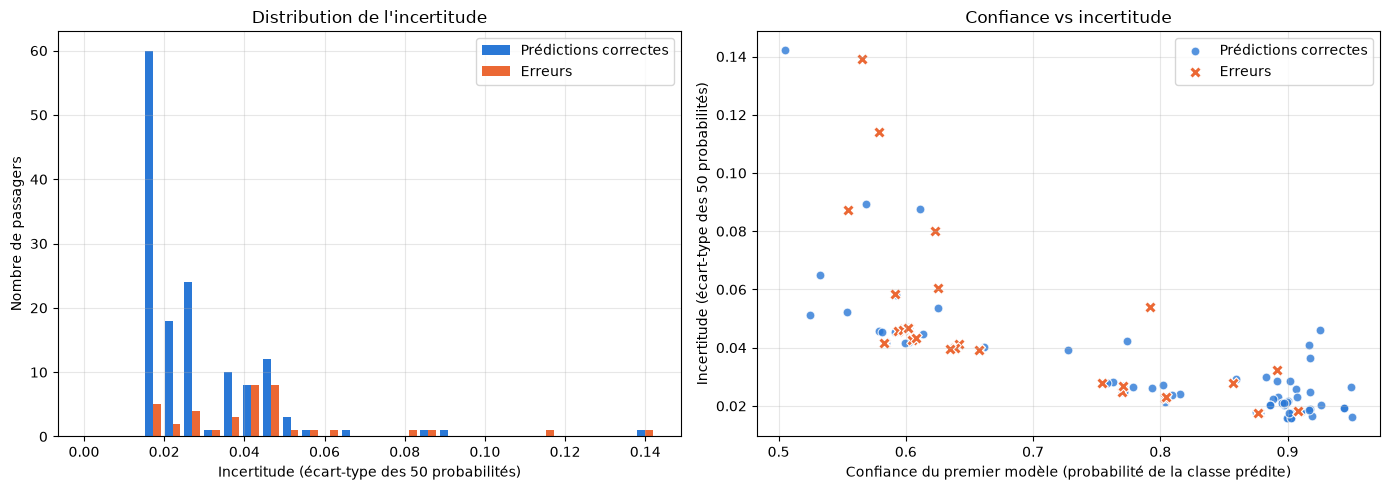

Incertitude médiane des prédictions correctes : 0.023
Incertitude médiane des erreurs               : 0.042


In [12]:
erreur = incertitude["Survived_predit"] != incertitude["Survived_reel"]
# Confiance du premier modele : probabilite de la classe qu'il predit (entre 0,5 et 1)
confiance = np.maximum(incertitude["proba_modele"], 1 - incertitude["proba_modele"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme de l'incertitude : predictions correctes et erreurs cote a cote
bins = np.linspace(0, incertitude["écart_type"].max(), 30)
ax1.hist(
    [incertitude.loc[~erreur, "écart_type"], incertitude.loc[erreur, "écart_type"]], bins=bins,
    color=["#2a78d6", "#eb6834"], label=["Prédictions correctes", "Erreurs"],
)
ax1.set_title("Distribution de l'incertitude")
ax1.set_xlabel("Incertitude (écart-type des 50 probabilités)")
ax1.set_ylabel("Nombre de passagers")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Nuage de points : confiance du premier modele vs incertitude
ax2.scatter(confiance[~erreur], incertitude.loc[~erreur, "écart_type"], marker="o", s=40,
            color="#2a78d6", edgecolor="white", linewidth=0.8, alpha=0.8, label="Prédictions correctes")
ax2.scatter(confiance[erreur], incertitude.loc[erreur, "écart_type"], marker="X", s=70,
            color="#eb6834", edgecolor="white", linewidth=0.8, label="Erreurs")
ax2.set_title("Confiance vs incertitude")
ax2.set_xlabel("Confiance du premier modèle (probabilité de la classe prédite)")
ax2.set_ylabel("Incertitude (écart-type des 50 probabilités)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Incertitude médiane des prédictions correctes :", round(incertitude.loc[~erreur, "écart_type"].median(), 3))
print("Incertitude médiane des erreurs               :", round(incertitude.loc[erreur, "écart_type"].median(), 3))

**Ce qu'on observe** : les erreurs sont en moyenne plus incertaines que les prédictions
correctes (incertitude médiane de 0,042 contre 0,023) : 72 % des prédictions correctes ont une
incertitude inférieure à 0,03, contre 29 % des erreurs. Mais les deux distributions se
chevauchent : aucune valeur d'incertitude ne sépare nettement les erreurs des bonnes
prédictions.

Sur le nuage de points (les passagers au profil identique se superposent : 179 passagers,
114 points distincts), l'incertitude baisse quand la confiance du premier modèle augmente, et
les erreurs forment deux groupes :

- **Confiance faible (moins de 0,7), incertitude élevée** : 25 des 38 erreurs, surtout des
  hommes de 1re classe qui ont survécu et des femmes de 3e classe qui sont décédées. Le modèle
  hésite et les 50 modèles divergent : un seuil de rejet peut écarter ces passagers.
- **Confiance forte (0,75 et plus), incertitude presque toujours faible** : 13 erreurs, surtout
  des hommes de 3e classe qui ont survécu. Les 50 modèles donnent des probabilités proches, et
  le premier modèle se trompe quand même : avec 5 colonnes, ces passagers ressemblent à ceux qui
  sont décédés. L'incertitude mesure la stabilité du modèle, pas la justesse de sa prédiction :
  aucun seuil de rejet ne rattrape ces erreurs.

**Question de réflexion :** si on refuse de prédire pour les passagers les plus incertains
(ils partent en vérification humaine), quel **seuil de rejet** faut-il fixer pour atteindre
85 % d'accuracy sur les passagers restants ? Et sur quelles données le choisir ?

Choisir ce seuil sur le jeu de test reviendrait à régler le modèle avec le test, alors que
l'étape 6 l'a posé : le test ne sert qu'une fois, à la fin. On choisit donc le seuil en
**cross-validation sur le jeu d'entraînement**, avec les mêmes 5 plis qu'à l'étape 6. Pour
chaque pli, le premier modèle et les 50 modèles bootstrap sont entraînés sur les 4 autres plis,
puis prédisent les passagers du pli mis de côté. Chaque passager du jeu d'entraînement reçoit
ainsi une prédiction et une incertitude calculées par des modèles qui ne l'ont jamais vu.

Un détail compte : dans un pli, les modèles ne s'entraînent que sur 4/5 des passagers, ce qui
gonfle leur incertitude. Pour qu'elle reste comparable à celle mesurée sur le jeu de test, chaque
tirage bootstrap compte autant de passagers que le jeu d'entraînement complet
(`taille_tirage=len(X_train)`).

On teste ensuite 50 seuils, du plus strict au plus permissif, et on retient le plus grand seuil
(donc le moins de rejets) qui atteint la cible.

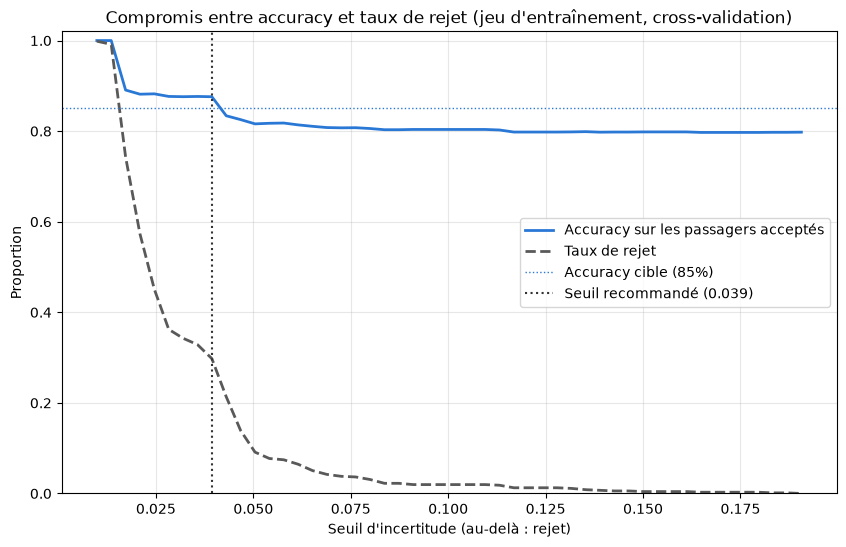

Accuracy sans rejet (cross-validation) : 0.798
Pour atteindre 85% d'accuracy sur les passagers acceptés :
  seuil d'incertitude : 0.039
  taux de rejet       : 29.8%
  accuracy obtenue    : 0.876


In [13]:
from sklearn.model_selection import StratifiedKFold

# Prediction et incertitude de chaque passager du jeu d'entrainement, par des modeles qui ne l'ont pas vu
correct_train = np.zeros(len(X_train), dtype=bool)
incertitude_train = np.zeros(len(X_train))
# StratifiedKFold(n_splits=5) : les memes 5 plis que cv=5 a l'etape 6
for indices_apprentissage, indices_validation in StratifiedKFold(n_splits=5).split(X_train, y_train):
    X_apprentissage, y_apprentissage = X_train.iloc[indices_apprentissage], y_train.iloc[indices_apprentissage]
    X_validation, y_validation = X_train.iloc[indices_validation], y_train.iloc[indices_validation]

    modele_pli = LogisticRegression(max_iter=5000).fit(X_apprentissage, y_apprentissage)
    correct_train[indices_validation] = modele_pli.predict(X_validation) == y_validation.to_numpy()
    incertitude_train[indices_validation] = probas_bootstrap(
        X_apprentissage, y_apprentissage, X_validation, taille_tirage=len(X_train)
    ).std(axis=0)

# Tester differents seuils de rejet : au-dela du seuil, le passager part en verification humaine
seuils = np.linspace(incertitude_train.min(), incertitude_train.max(), 50)
accuracies_acceptes = []
taux_rejet = []
for seuil in seuils:
    acceptes = incertitude_train <= seuil
    accuracies_acceptes.append(correct_train[acceptes].mean())
    taux_rejet.append(1 - acceptes.mean())
accuracies_acceptes = np.array(accuracies_acceptes)
taux_rejet = np.array(taux_rejet)

# Seuil recommande : le plus grand seuil (donc le moins de rejets) qui atteint l'accuracy cible
accuracy_cible = 0.85
atteint = accuracies_acceptes >= accuracy_cible
indice_recommande = np.flatnonzero(atteint).max() if atteint.any() else None

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(seuils, accuracies_acceptes, color="#2a78d6", linewidth=2, label="Accuracy sur les passagers acceptés")
ax.plot(seuils, taux_rejet, color="0.35", linestyle="--", linewidth=2, label="Taux de rejet")
ax.axhline(accuracy_cible, color="#2a78d6", linestyle=":", linewidth=1, label=f"Accuracy cible ({accuracy_cible:.0%})")
if indice_recommande is not None:
    ax.axvline(seuils[indice_recommande], color="0.2", linestyle=":", linewidth=1.5,
               label=f"Seuil recommandé ({seuils[indice_recommande]:.3f})")
ax.set_ylim(0, 1.02)
ax.set_xlabel("Seuil d'incertitude (au-delà : rejet)")
ax.set_ylabel("Proportion")
ax.set_title("Compromis entre accuracy et taux de rejet (jeu d'entraînement, cross-validation)")
ax.legend(loc="center right")
ax.grid(True, alpha=0.3)
plt.show()

print("Accuracy sans rejet (cross-validation) :", round(correct_train.mean(), 3))
if indice_recommande is not None:
    print(f"Pour atteindre {accuracy_cible:.0%} d'accuracy sur les passagers acceptés :")
    print(f"  seuil d'incertitude : {seuils[indice_recommande]:.3f}")
    print(f"  taux de rejet       : {taux_rejet[indice_recommande]:.1%}")
    print(f"  accuracy obtenue    : {accuracies_acceptes[indice_recommande]:.3f}")
else:
    print(f"Impossible d'atteindre {accuracy_cible:.0%} d'accuracy, quel que soit le seuil.")

**Ce qu'on observe** : sans rejet, le premier modèle obtient 0,798 d'accuracy en
cross-validation, le même score qu'à l'étape 6. Pour atteindre 85 %, le seuil recommandé est
0,039 : 29,8 % des passagers du jeu d'entraînement sont rejetés, et l'accuracy sur les autres
monte à 0,876.

La courbe ne passe pas en douceur par 85 % : entre les seuils 0,043 et 0,039, 60 passagers
d'incertitude voisine sont rejetés d'un coup, et l'accuracy saute de 0,834 à 0,876. Rendre le
seuil plus strict ne sert ensuite presque à rien : l'accuracy reste entre 0,876 et 0,891 pendant
que le taux de rejet grimpe jusqu'à 74 %. Une cible de 90 % n'est atteinte qu'en rejetant plus
de 99 % des passagers : elle est hors de portée de ce modèle.

**Question de réflexion :** ce seuil a été choisi sans jamais regarder le jeu de test.
Tient-il ses promesses sur ce jeu de test ?

In [14]:
# Application unique du seuil retenu au jeu de test
if indice_recommande is None:
    print("Aucun seuil retenu : la cible n'est pas atteinte sur le jeu d'entraînement.")
else:
    seuil_retenu = seuils[indice_recommande]
    acceptes_test = incertitude["écart_type"] <= seuil_retenu

    print(f"Seuil de rejet retenu sur le jeu d'entraînement : {seuil_retenu:.3f}")
    print(f"Passagers du test rejetés : {(~acceptes_test).sum()} sur {len(incertitude)} "
          f"({1 - acceptes_test.mean():.1%})")
    print("Accuracy sur tous les passagers du test     :",
          round(accuracy_score(incertitude["Survived_reel"], incertitude["Survived_predit"]), 3))
    print("Accuracy sur les passagers acceptés du test :",
          round(accuracy_score(incertitude.loc[acceptes_test, "Survived_reel"],
                               incertitude.loc[acceptes_test, "Survived_predit"]), 3))

Seuil de rejet retenu sur le jeu d'entraînement : 0.039
Passagers du test rejetés : 51 sur 179 (28.5%)
Accuracy sur tous les passagers du test     : 0.788
Accuracy sur les passagers acceptés du test : 0.883


**Ce qu'on observe** : appliqué une seule fois au jeu de test, le seuil de 0,039 rejette 51
passagers sur 179 (28,5 %), et l'accuracy sur les passagers acceptés atteint 0,883, contre 0,788
sans rejet. Le test confirme ce que la cross-validation annonçait (29,8 % de rejet, 0,876
d'accuracy) : comme le seuil a été choisi sans regarder le test, ce résultat est une estimation
honnête. Sur 179 passagers, il reste une estimation : l'étape 6 a montré qu'un score varie d'un
découpage à l'autre.

Comme le seuil de décision (étape 5), le seuil de rejet se choisit selon le coût métier : gagner
près de 10 points d'accuracy vaut-il de faire vérifier à la main plus d'un passager sur quatre ?
Et le rejet ne rattrape pas les erreurs commises avec assurance (graphique « Confiance vs
incertitude ») : pour les réduire, il faut un meilleur modèle, avec plus d'informations sur les
passagers. C'est l'objet des notebooks suivants.